## **Task: SIG731 : Task 2P - Working with numpy Vectors (Unidimensional Data)**

#### **Name: Isha Shukla**
#### Student number: 225170943
#### E-mail - isha03shukla04@gmail.com

### Introduction:

This report provides an in-depth analysis of the `BTC-to-USD` exchange rate for the fourth quarter (Q4) of 2023 using Python and NumPy. 

#### Objective:
The primary objectives include calculating statistical aggregates, identifying days with the highest and lowest prices, and analyzing daily price variations through visualizations. The analysis strictly adheres to vectorized operations to leverage the computational efficiency of NumPy. Furthermore, insights are presented through graphical plots to help interpret trends and variations during this period.

The focus is to ensure a comprehensive understanding of the dataset's properties while applying sound analytical techniques. The methods are discussed and explained throughout, with an emphasis on clarity and reproducibility.



In [1]:
pip install yfinance #Installing yfinance

Note: you may need to restart the kernel to use updated packages.


### Q1: Download the daily close BTC-to-USD data, from 2023-01-01 up to 2023-12-31

In [2]:
import yfinance as yf #importing yfinance library

# Define the ticker and period
ticker = "BTC-USD"
start_date = "2023-01-01"  # Adjust according to period1
end_date = "2024-01-01"    # Adjust according to period2

# Fetch historical data and downloading it my local folder
data = yf.download(ticker, start=start_date, end=end_date, interval="1d")

# Saving it to CSV
data.to_csv("BTC-USD_Historical.csv")

print("Data downloaded and saved as BTC-USD_Historical.csv")

[*********************100%***********************]  1 of 1 completed

Data downloaded and saved as BTC-USD_Historical.csv


In [3]:
data.head() #first five rows of the dataset

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2023-01-01,16625.080078,16630.439453,16521.234375,16547.914062,9244361700
2023-01-02,16688.470703,16759.343750,16572.228516,16625.509766,12097775227
2023-01-03,16679.857422,16760.447266,16622.371094,16688.847656,13903079207
2023-01-04,16863.238281,16964.585938,16667.763672,16680.205078,18421743322
2023-01-05,16836.736328,16884.021484,16790.283203,16863.472656,13692758566


In [4]:
data.tail() #last five rows of the dataset

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2023-12-27,43442.855469,43683.160156,42167.582031,42518.468750,25260941032
2023-12-28,42627.855469,43804.781250,42318.550781,43468.199219,22992093014
2023-12-29,42099.402344,43124.324219,41424.062500,42614.644531,26000021055
2023-12-30,42156.902344,42584.125000,41556.226562,42091.753906,16013925945
2023-12-31,42265.187500,42860.937500,41998.253906,42152.097656,16397498810


In [5]:
data.info() #datatype and columns information

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 365 entries, 2023-01-01 to 2023-12-31
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   365 non-null    float64
 1   (High, BTC-USD)    365 non-null    float64
 2   (Low, BTC-USD)     365 non-null    float64
 3   (Open, BTC-USD)    365 non-null    float64
 4   (Volume, BTC-USD)  365 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 17.1 KB


### Q2: Use numpy.genfromtxt or numpy.loadtxt to read the above BTC-to-USD data as a numpy vector named rates.
Option: You can use a spreadsheet application such as LibreOffice Calc or MS Excel to manually
remove everything except the numeric values in the Close column. The column labels should also
be manually deleted. Export these observations to a CSV file (which should only contain numbers,
one per line). You can also use features in numpy.genfromtxt or `numpy.loadtxt` to remove
them.

In [6]:
import numpy as np #importing Numpy library
import matplotlib.pyplot as plt #importing matplotlib library for data visualization

In [7]:
# Load the Close rates from a cleaned CSV file
rates = np.loadtxt('/Users/ishashukla/Desktop/Deakin Uni/SIG731- Data Wrangling/BTC-USD-Close.csv')

# Display the first few rates
print("Rates:", rates[:10])

Rates: [16625.08008 16688.4707  16679.85742 16863.23828 16836.73633 16951.96875
 16955.07813 17091.14453 17196.55469 17446.29297]


In [8]:
print(f"Loaded {len(rates)} rates:")
print(rates[:5])  # Display the first 5 rates

Loaded 365 rates:
[16625.08008 16688.4707  16679.85742 16863.23828 16836.73633]


### Q4: For the fourth quarter of the year only (Q4 2023; days 274–365 inclusive),determine and display(in a readable manner) the following aggregates:
• arithmetic mean,<br>
• minimum,<br>
• the first quartile,<br>
• median,<br>
• the third quartile,<br>
• maximum,<br>
• standard deviation,<br>
• interquartile range.<br>

- **Arithmetic Mean:** The sum of all values divided by the number of values; represents the dataset's average.
- **Minimum:** The smallest value in the dataset.
- **First Quartile (Q1):** The value below which 25% of the data falls; the lower quartile.
- **Median:** The middle value in the dataset when ordered, or the average of the two middle values if the dataset size is even.
- **Third Quartile (Q3):** The value below which 75% of the data falls; the upper quartile.
- **Maximum:** The largest value in the dataset.
- **Standard Deviation:** A measure of the spread of values around the mean, indicating the dataset's variability.
- **Interquartile Range (IQR):** The range between the first quartile (Q1) and the third quartile (Q3), measuring the middle 50% of the data.

In [9]:
# Extract Q4 2023 data (days 274–365, zero-indexed)
q4_rates = rates[274:366]  # Using zero-based indexing

# Calculate aggregates
mean_rate = np.mean(q4_rates)
min_rate = np.min(q4_rates)
q1_rate = np.percentile(q4_rates, 25)  # First quartile (25th percentile)
median_rate = np.median(q4_rates)
q3_rate = np.percentile(q4_rates, 75)  # Third quartile (75th percentile)
max_rate = np.max(q4_rates)
std_dev_rate = np.std(q4_rates, ddof=1)  # Standard deviation with sample correction (ddof=1)
iqr_rate = q3_rate - q1_rate  # Interquartile range (IQR)

# Display results
print("Aggregates for Q4 2023 (Days 274–365):")
print(f"Arithmetic Mean: {mean_rate:.2f}")
print(f"Minimum: {min_rate:.2f}")
print(f"Q1: {q1_rate:.2f}")
print(f"Median: {median_rate:.2f}")
print(f"Q3: {q3_rate:.2f}")
print(f"Maximum: {max_rate:.2f}")
print(f"Standard Deviation: {std_dev_rate:.2f}")
print(f"IQR: {iqr_rate:.2f}")

Aggregates for Q4 2023 (Days 274–365):
Arithmetic Mean: 36387.78
Minimum: 26756.80
Q1: 33905.66
Median: 37054.52
Q3: 42039.75
Maximum: 44166.60
Standard Deviation: 5601.42
IQR: 8134.09


### Q4: Call matplotlib.pyplot.plot(days, rates, <...further_arguments...>) to draw the Q4 2023 data (with 274 denoting 1 October), using red solid line segments. Call matplotlib.pyplot.title to add the plot title. Discuss what you see.

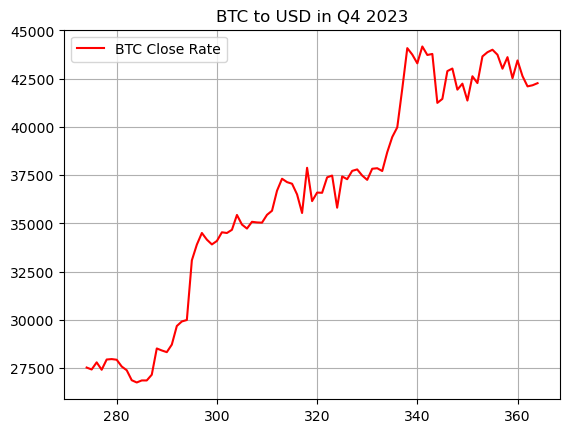

In [10]:
# Generate days for Q4 (1 October = day 274)
q4_days = np.arange(274, 365)  # Days 274 to 365 (length 92)

# Ensure the lengths of q4_days and q4_rates match
#print("Length of q4_days:", len(q4_days))
#print("Length of q4_rates:", len(q4_rates))

# Plot the Q4 data
plt.plot(q4_days, q4_rates, color='red', linestyle='-', label='BTC Close Rate')  # Red solid line
plt.title('BTC to USD in Q4 2023')
#plt.xlabel('Day of the Year (Starting from 1 Oct = Day 274)')
#plt.ylabel('BTC Close Rate (USD)')
plt.legend()
plt.grid(True)  # Optional: Adds a grid for better visualization
plt.show()

#### Observation:
The  graph  "BTC to USD in Q4 2023" shows a significant upward trend in the closing rate of Bitcoin (BTC) against the USD throughout the fourth quarter of 2023. Starting around 27,500 USD, the rate climbs sharply to approximately 35000 USD and continues its ascent, peaking at around 44000 USD before stabilizing. Despite some minor fluctuations post-peak, the overall trend remains positive, indicating Bitcoin's robust performance and volatility during this period. These insights underscore the dynamic nature of Bitcoin's market behavior in the last quarter of 2023.

### Q5: Determine the day numbers (with 274 denoting 1 October) with the lowest and highest observed prices in Q4 2023. 

In [11]:
# Find the day with the lowest price
min_price_index = np.argmin(q4_rates) #function returns the position of the minimum value within an array.
min_price_day = q4_days[min_price_index]
min_price = q4_rates[min_price_index]

# Find the day with the highest price
max_price_index = np.argmax(q4_rates) #function returns the position of the maximum value within an array.
max_price_day = q4_days[max_price_index]
max_price = q4_rates[max_price_index]

# Display the results
print(f"Lowest price was on day {min_price_day+1} ({min_price:.2f}).")
print(f"Highest price was on day {max_price_day+1} ({max_price:.2f}).")

Lowest price was on day 285 (26756.80).
Highest price was on day 342 (44166.60).


### Q6: Using matplotlib.pyplot.boxplot, draw a horizontal box-and-whisker plot for the Q4 2023
- daily price increases/decreases as obtained by a call to numpy.diff.
- Using an additional call to matplotlib.pyplot.plot, mark the arithmetic mean on the box
- plot with a green “x”

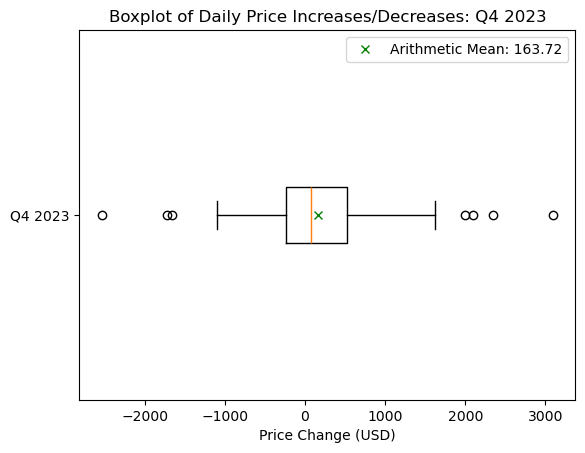

In [12]:
# Calculate the daily price increases/decreases
daily_changes = np.diff(q4_rates)

# Generate the boxplot for daily changes
plt.boxplot(daily_changes, vert=False)

# Calculate the arithmetic mean of the daily changes
mean_change = np.mean(daily_changes)

# Mark the mean on the boxplot with a green "x"
plt.plot(mean_change, 1, 'gx', label=f'Arithmetic Mean: {mean_change:.2f}')

# Add labels and title
plt.title('Boxplot of Daily Price Increases/Decreases: Q4 2023')
plt.xlabel('Price Change (USD)')
plt.yticks([1], ['Q4 2023'])

# Display the plot
plt.legend()
plt.show()

The boxplot "Boxplot of Daily Price Increases/Decreases: Q4 2023" showcases the distribution of daily price changes in USD for Q4 2023. The arithmetic mean is 163.72 USD, and outliers are present on both sides, beyond the whiskers. There are total 7 outliers seen from visualization plot.

### Q7: Count (programmatically,using the vectorised relational operators from numpy) how many outliers the boxplot contains (for the definition of an outlier, consult Section 2.3 of our learning materials on the unit site or Section 5.1 in the Book). In your own words, explain what such outliers might mean in the current context.

In [16]:
# Calculate Q1, Q3, and IQR
Q1 = np.percentile(daily_changes, 25)
Q3 = np.percentile(daily_changes, 75)
IQR = Q3 - Q1

# Calculate the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers using vectorized relational operators
outliers = (daily_changes < lower_bound) | (daily_changes > upper_bound)

# Count the number of outliers
num_outliers = np.sum(outliers)
# Print the results
print(f"There are {num_outliers} outliers.") 

There are 7 outliers.


### Conclusion:
Firstly, we downloaded the dataset from yfinance.
The analysis of `BTC-to-USD exchange rates for Q4 2023` provides a comprehensive understanding of the price trends and variability during this period. Key statistical measures, such as the mean, quartiles, and standard deviation, highlight the central tendencies and dispersion within the dataset. Visualization techniques further elucidated day-to-day variations and overall trends.

**Aggregate data for Q4 2023 (Days 274–365) includes:**
Arithmetic Mean: 36387.78 USD
Minimum: 26756.80 USD
Q1: 33905.66 USD
Median: 37054.52 USD
Q3: 42039.75 USD
Maximum: 44166.60 USD
Standard Deviation: 5601.42 USD
IQR: 8134.09 USD

The graph "BTC to USD in Q4 2023" shows a significant upward trend in the closing rate of Bitcoin (BTC) against the USD throughout the fourth quarter of 2023. Starting around 27,500 USD, the rate climbs sharply to approximately 35,000 USD, continues its ascent to peak at around 44,000 USD, and then stabilizes. Despite minor fluctuations post-peak, the overall trend remains positive, indicating Bitcoin's robust performance and volatility during this period. These insights underscore the dynamic nature of Bitcoin's market behavior in the last quarter of 2023.

The boxplot "Boxplot of Daily Price Increases/Decreases: Q4 2023" showcases the distribution of daily price changes in USD for Q4 2023. With an arithmetic mean of 163.72 USD, the presence of outliers on both sides beyond the whiskers, and a total of 7 outliers observed, the data highlights the variability and occasional significant deviations in daily price changes.

In conclusion, the analysis demonstrated the efficacy of using NumPy for large-scale numerical computations and matplotlib for data visualization. Future extensions could include analyzing correlations with other financial indicators, exploring seasonal trends, or incorporating machine learning models to forecast future prices. These additions would enhance the depth and breadth of the analysis, providing actionable insights for stakeholders.
